### Задача 1
Примените алгоритм Metropolis для генерации выборки из распределения с плотностью
p(x) = 0.3N(-4, 2) + 0.7N(3, 6), где N(a, b) - плотность нормального распределения со средним a и дисперсией b. Для наглядности, ниже приведен график плотности смеси. Покажите, что гистограмма, построенная по выборке, приближает заданную плотность смеси.

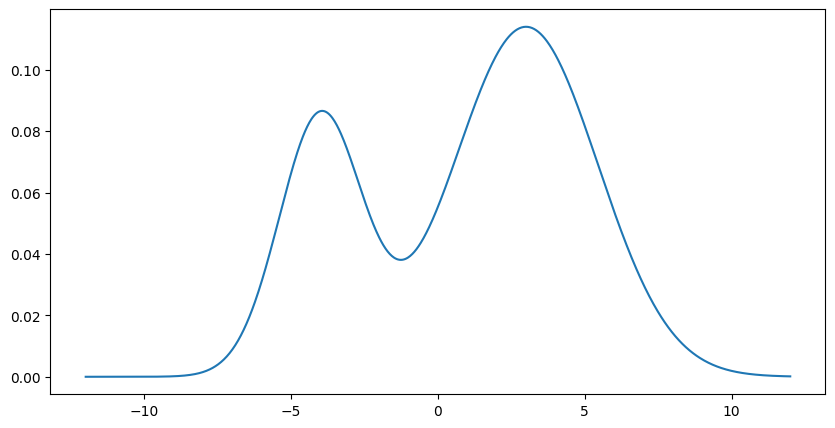

In [36]:
from scipy.stats import norm

x = np.linspace(-12, 12, 1000)
y = 0.3*norm(-4, np.sqrt(2)).pdf(x) + 0.7*norm(3, np.sqrt(6)).pdf(x)

fig, ax = plt.subplots(1, figsize=(10, 5))
fig.patch.set_facecolor('xkcd:white')
plt.plot(x, y)
plt.show()

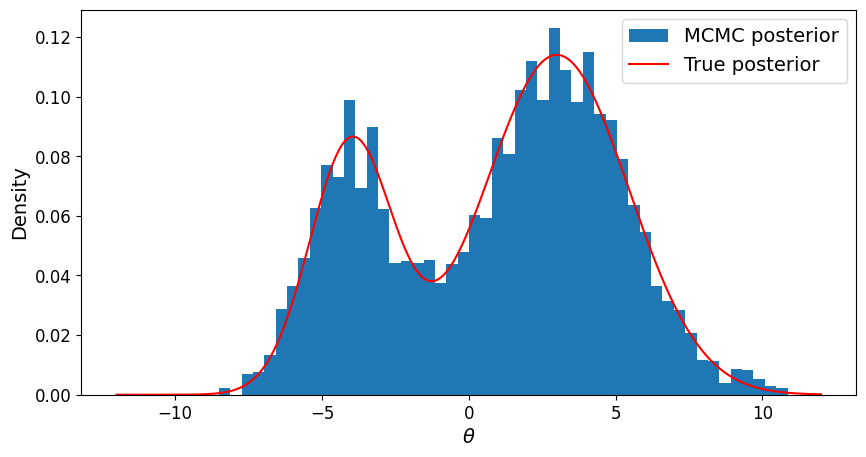

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def metroplis(start, value, proposal, niter, nburn=0, **kwargs):
    current = start
    post = [current]
    for i in range(niter):
        proposed = proposal(current, **kwargs)
        p = value(proposed, **kwargs) / value(current, **kwargs)
        if np.random.rand() < p:
            current = proposed
        post.append(current)
    return post[nburn:]

def proposal(current, sigma, **kwargs):
    _ = kwargs
    current = np.asarray(current)
    sigma = np.asarray(sigma)
    return current + sigma * np.random.randn(*current.shape)

def value(theta, **kwargs):
    _ = kwargs
    if theta < -12 or theta > 12:
        return 0
    else:
        return likelihood(theta)

thetas = np.linspace(0, 1, 200)
likelihood = lambda thetas: 0.3*norm(-4, np.sqrt(2)).pdf(thetas) + 0.7*norm(3, np.sqrt(6)).pdf(thetas)
post = metroplis(0.2, value, proposal, 6000, sigma=4)

x = np.linspace(-12, 12, 1000)
y = 0.3*norm(-4, np.sqrt(2)).pdf(x) + 0.7*norm(3, np.sqrt(6)).pdf(x)

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor('xkcd:white')
plt.hist(post, bins=50, density=True, label='MCMC posterior')
plt.plot(x, y, label='True posterior', c='red')
plt.legend(fontsize=14)
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Задача 2
Рассмотрим граф $G=(V,E)$, вершинам которого случайным образом приписаны значения 0 и 1 так, что смежные вершины не могут одновременно иметь значение 1. Пример допустимой расстановки значений по вершинам графа показан на картинке ниже (черные вершины имеют значение 1, белые - 0):

<!-- ![img](http://www.mathematik.uni-ulm.de/stochastik/lehre/ss06/markov/skript_engl/bild4.jpg) -->

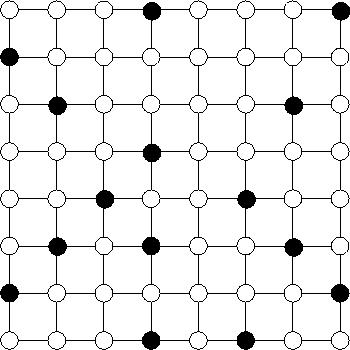

Как оценить, сколько в среднем закрашенных вершин будет иметь такой граф?

Сформулируем задачу в математических терминах.

Пусть $\xi \in \{0,1\}^{V}$ обозначает конфигурацию графа (расстановку 0 и 1 по вершинам). Назовем конфигурацию допустимой, если вершины, соединенные ребрами, не имеют одновременно значения 1. Пусть $Z_G$ - общее количество допустимых конфигураций. Зададим  распределение на множестве всех $2^V$ конфигураций:
$$\begin{equation*}
\mu(\xi) =
 \begin{cases}
   \frac{1}{Z_G}, &\text{$\xi$ - допустимая конфигурация}\\
   0, &\text{иначе.}
 \end{cases}
\end{equation*}$$
Обозначим $n(\xi)$ - число закрашенных вершин в конфигурации $\xi$. Тогда
$$
{\rm E} n(\xi) = \sum\limits_{x \in \{0,1\}^V} n(x) \mu(x) = \frac{1}{Z_G} \sum\limits_{x \in \{0,1\}^V} n(x) {\rm I}_{\{x - \text{допустимая} \}}
$$

Явно перебирать все $x \in \{0,1\}^{V}$ не представляется возможным. Мы могли бы попробовать оценить ${\rm E} n(\xi)$, используя закон больших чиcел:
$$
{\rm E} n(\xi) \approx \frac{1}{N} \sum\limits_{i=1}^{N} n(\xi_i), \text{где $\xi_i$, $i=1,...,N$ - выборка случайных допустимых графов. }
$$

Для моделирования выборки можно применить метод MCMC:
1. выбираем случайную вершину
2. если в вершине можно заменить цвет - заменяем с вероятностью 0.5
3. добавляем граф в выборку
4. переходим на шаг 1

Задание
* Оценить  ${\rm E} n(\xi)$ для графа 10х10
* Построить график распределеиня $n(\xi)$

Совет: проверьте алгоритм на графах размера $2\times 2$. Ваш ответ должет быть близок к точному ответу (0+1+1+1+1+2+2)/7 = 8/7.

En(ξ)= 23.653333333333332


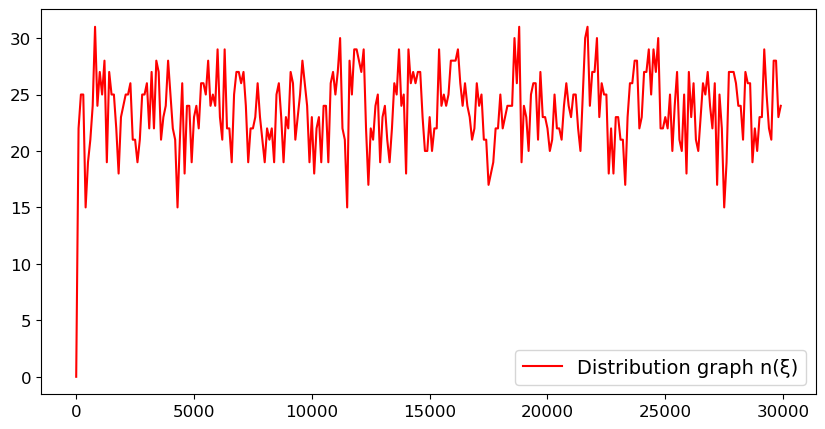

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def MCMC(graph, n):
  i=np.random.randint(0, n)
  j=np.random.randint(0, n)
  if graph[i][j]==0:
    if i==0:
      if j==0:
        if graph[i][j+1]!=1 and graph[i+1][j]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
      elif j==n-1:
        if graph[i][j-1]!=1 and graph[i+1][j]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
      else:
        if graph[i][j-1]!=1 and graph[i+1][j]!=1 and graph[i][j+1]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
    elif i==n-1:
      if j==0:
        if graph[i-1][j]!=1 and graph[i][j+1]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
      elif j==n-1:
        if graph[i][j-1]!=1 and graph[i-1][j]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
      else:
        if graph[i][j-1]!=1 and graph[i-1][j]!=1 and graph[i][j+1]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
    else:
      if j==0:
        if graph[i-1][j]!=1 and graph[i][j+1]!=1 and graph[i+1][j]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
      elif j==n-1:
        if graph[i-1][j]!=1 and graph[i][j-1]!=1 and graph[i+1][j]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
      else:
        if graph[i-1][j]!=1 and graph[i][j-1]!=1 and graph[i+1][j]!=1 and graph[i][j+1]!=1:
          if np.random.randint(0, 2)==1:
            graph[i][j]=1
  else:
    if np.random.randint(0, 2)==1:
      graph[i][j]=0
  return graph

n=10
N=30000
n_ksi=np.zeros(N)
graph=np.zeros((n, n))
for i in range (N):
  n_ksi[i]=np.sum(MCMC(graph, n))

print('En(ξ)=', np.sum(n_ksi[::100])/(N/100))

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor('xkcd:white')
plt.plot(np.arange(0, 30000, 100), n_ksi[::100], label='Distribution graph n(ξ)', c='red')
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()